
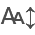

In [1]:
import os
from datetime import date, datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kurtosis, skew
from scipy.signal import find_peaks

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

import ruptures as rpt

from pathlib import Path
import pytz

%load_ext autoreload
%autoreload 2

from itables import init_notebook_mode

init_notebook_mode(all_interactive=True)

## Feature Extraction

In [2]:
def statistical_features(arr):
    vmin = np.amin(arr)
    vmax = np.amax(arr)
    mean = np.mean(arr)
    std = np.std(arr)
    return vmin, vmax, mean, std

def shape_features(arr):
    skewness = skew(arr)
    kurt = kurtosis(arr)
    return skewness, kurt

## Pre-processing

In [ ]:
# For loading the original nurses data

# import_path = f'{user}'
# export_path = f'{user}'

# rightEDAdatapath  = f'{import_path}/EDA.csv'
# rightHRdatapath   = f'{import_path}/HR.csv'
# rightTEMPdatapath = f'{import_path}/TEMP.csv'

# rightHRdatapath = np.loadtxt(rightHRdatapath, delimiter = ',')
# rightHRdatapath = np.repeat(rightHRdatapath, 4)
# np.savetxt('hr_new.csv', rightHRdatapath, delimiter = ',')

# edat =  pd.read_csv(f'{user}/EDA.csv',  header = 2,  names = ['EDA'])
# hrt =   pd.read_csv(f'hr_new.csv',      header = 12, names = ['HR'])
# # tempt = pd.read_csv(f'{user}/Temp.csv', header = 2,  names = ['TEMP'])
# gt =    pd.read_csv(f'{user}/EDA.csv',  nrows  = 1)

# reference_time = gt.iloc[0,0]
# min_len = min(len(edat), len(hrt), len(tempt))

# eda = edat.iloc[:min_len, 0]
# hrt = hrt.iloc[:min_len, 0]
# tempt = tempt.iloc[:min_len, 0]
# df_original = pd.concat([eda, hrt, tempt], axis = 1)

In [4]:
jerusalem_tz = pytz.timezone('Asia/Jerusalem')
hz = 4
user = "TRAIL005"
processsed_data_path = Path("../../data/embrace_plus/participant_processed_data")
user_processsed_data_path = processsed_data_path.joinpath(Path(user))
user_all_data_path = user_processsed_data_path.joinpath("all_data.parquet")
if user_all_data_path.exists():
    all_data = pd.read_parquet(user_all_data_path, engine='fastparquet')
else:
    all_eda_df = pd.read_parquet(user_processsed_data_path.joinpath("all_eda_df" + ".parquet"), engine='fastparquet')
    all_hr_df = pd.read_parquet(user_processsed_data_path.joinpath("all_hr_df" + ".parquet"), engine='fastparquet')
    all_temp_df = pd.read_parquet(user_processsed_data_path.joinpath("all_temp_df" + ".parquet"), engine='fastparquet')

    lean_eda = pd.DataFrame({'EDA': all_eda_df["value"].values}, index=all_eda_df["rounded_timestamp"].values)
    lean_hr= pd.DataFrame({'HR': all_hr_df["hr_per_minute"].values}, index=all_hr_df["rounded_timestamp"].values)
    lean_temp= pd.DataFrame({'temp': all_temp_df["value"].values}, index=all_temp_df["rounded_timestamp"].values)
    
    display(lean_eda)
    display(lean_hr)
    display(lean_temp)
        
    all_data = pd.merge(lean_eda, lean_hr, left_index=True, right_index=True, how='inner')
    all_data = pd.merge(all_data, lean_temp, left_index=True, right_index=True, how='inner')
    display(all_data)

    all_data.to_parquet(user_all_data_path)

In [5]:
all_data.index = all_data.index.tz_localize(jerusalem_tz)
all_data = all_data.dropna()
display(all_data)

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [6]:
def sort_longest_continuous_sections(df: pd.DataFrame):
    if df.empty or len(df) <= 1:
        return pd.DataFrame()

    # Ensure the index is sorted
    df = df.sort_index()
    time_diffs = df.index.diff()
    continuous_sections = []
    current_section_start_index = 0
    print(len(time_diffs))
    for i in range(1, len(time_diffs)):
        if time_diffs[i] != time_diffs[i - 1]:
            continuous_sections.append(df.iloc[current_section_start_index:i])
            current_section_start_index = i

    # Add the last continuous section
    continuous_sections.append(df.iloc[current_section_start_index:])

    if not continuous_sections:
        return pd.DataFrame()

    sorted_sections = sorted(continuous_sections, key=len, reverse=True)
    return sorted_sections

    
print(f"{user} all data duration: {all_data.index[0], all_data.index[-1]}")

minimum_section_time_in_seconds = 5 * 60
start_time = pd.to_datetime("2025-05-27")
end_time = pd.to_datetime("2025-05-28")

date_range_data = all_data[(all_data.index.date == start_time.date()) | (all_data.index.date == end_time.date())]
sorted_data_sections = sort_longest_continuous_sections(date_range_data)
print(f"len(sorted_data_sections) {len(sorted_data_sections)}")
data_sections = [section for section in sorted_data_sections if len(section) >= (minimum_section_time_in_seconds * hz)]
reference_times = [section.index[0] for section in data_sections]
display(reference_times)
print(f"len(data_sections) {len(data_sections)}")
data = data_sections[0]
print(data.index[0], data.index[-1])
display(data)

TRAIL005 all data duration: (Timestamp('2025-05-14 12:43:00+0300', tz='Asia/Jerusalem'), Timestamp('2025-06-17 05:18:42.750000+0300', tz='Asia/Jerusalem'))
524643
len(sorted_data_sections) 28


[Timestamp('2025-05-27 15:01:00.250000+0300', tz='Asia/Jerusalem'),
 Timestamp('2025-05-28 16:06:59+0300', tz='Asia/Jerusalem'),
 Timestamp('2025-05-27 02:26:10.250000+0300', tz='Asia/Jerusalem'),
 Timestamp('2025-05-27 00:00:00.250000+0300', tz='Asia/Jerusalem'),
 Timestamp('2025-05-28 13:54:00.250000+0300', tz='Asia/Jerusalem'),
 Timestamp('2025-05-28 12:31:00.250000+0300', tz='Asia/Jerusalem'),
 Timestamp('2025-05-28 11:17:00.250000+0300', tz='Asia/Jerusalem'),
 Timestamp('2025-05-27 14:01:00.250000+0300', tz='Asia/Jerusalem'),
 Timestamp('2025-05-28 08:32:08+0300', tz='Asia/Jerusalem')]

len(data_sections) 9
2025-05-27 15:01:00.250000+03:00 2025-05-28 08:32:07.750000+03:00


Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [7]:
# array = df_original.values
# data = pd.DataFrame(array)
# data.columns = ['EDA','HR','temp']

cols = [
    'EDA_Mean','EDA_Min','EDA_Max','EDA_Std', 'EDA_Kurtosis', 'EDA_Skew','EDA_Num_Peaks','EDA_Amphitude','EDA_Duration',
    'HR_Mean','HR_Min','HR_Max','HR_Std','HR_RMS','temp_Mean', 'temp_Min','temp_Max','temp_Std'
]
def get_features(cols, data):
    df_features = pd.DataFrame(columns=cols)
    
    index = 0
    
    for i in range(0,len(data['EDA']), 20):
        df_partial = data.iloc[i:i+ 40,]
        plen = len(df_partial['EDA'])
        
        if plen < 40:
            continue
        
        eda = df_partial['EDA'].values
        hr = df_partial['HR'].values
        temp = df_partial['temp'].values
    
        eda_min, eda_max, eda_mean, eda_std = statistical_features(eda)
        hr_min, hr_max, hr_mean, hr_std = statistical_features(hr)
        temp_min, temp_max, temp_mean, temp_std = statistical_features(temp)
        eda_skew, eda_kurtosis = shape_features(eda)
        
        hr_rms = np.sqrt(np.mean(np.square(np.ediff1d(hr))))
        temp_rms= np.sqrt(np.mean(np.square(np.ediff1d(temp))))
    
        peaks,properties = find_peaks(eda, width=5)
        num_Peaks = len(peaks)
        
        prominences = np.array(properties['prominences'])
        widths = np.array(properties['widths'])
        amphitude = np.sum(prominences)
        duration = np.sum(widths)
    
        df_features.loc[index] = [eda_mean, eda_min, eda_max, eda_std, eda_kurtosis, eda_skew, num_Peaks, amphitude, duration, hr_mean, hr_min, hr_max, hr_std,hr_rms, temp_mean, temp_min, temp_max, temp_std]
        index = index+1
    return df_features

df_features_sections = [get_features(cols, data_section) for data_section in data_sections]

In [8]:
def create_lagged_features(df_features):
    cols = list(map(str, range(30, 0, -1)))
    df_lag_features = pd.DataFrame(columns=cols)
    df_lag_features = pd.concat([
        df_features['HR_Mean'].shift(10),  df_features['HR_Mean'].shift(9),    df_features['HR_Mean'].shift(8),
        df_features['HR_Mean'].shift(7),   df_features['HR_Mean'].shift(6),    df_features['HR_Mean'].shift(5),
        df_features['HR_Mean'].shift(4),   df_features['HR_Mean'].shift(3),    df_features['HR_Mean'].shift(2),
        df_features['HR_Mean'].shift(1),   df_features['temp_Mean'].shift(10), df_features['temp_Mean'].shift(9),
        df_features['temp_Mean'].shift(8), df_features['temp_Mean'].shift(7),  df_features['temp_Mean'].shift(6),
        df_features['temp_Mean'].shift(5), df_features['temp_Mean'].shift(4),  df_features['temp_Mean'].shift(3),
        df_features['temp_Mean'].shift(2), df_features['temp_Mean'].shift(1),  df_features['EDA_Mean'].shift(10),
        df_features['EDA_Mean'].shift(9),  df_features['EDA_Mean'].shift(8),   df_features['EDA_Mean'].shift(7),
        df_features['EDA_Mean'].shift(6),  df_features['EDA_Mean'].shift(5),   df_features['EDA_Mean'].shift(4),
        df_features['EDA_Mean'].shift(3),  df_features['EDA_Mean'].shift(2),   df_features['EDA_Mean'].shift(1)], axis=1)
    df_lag_features.columns = cols
    df_lag_features = df_lag_features.dropna()
    return df_lag_features

df_lag_features_sections = [create_lagged_features(df_features) for df_features in df_features_sections]

In [9]:
df_totals = []
for i in range(len(df_features_sections)):
    df_temp = df_features_sections[i].iloc[30:, 0:31]
    df_total = pd.concat([df_lag_features_sections[i].reset_index(drop=True), df_temp.reset_index(drop=True)], axis=1)
    df_total = df_total.dropna()
    df_totals.append(df_total)
    
display(df_totals[0])


Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


## Stress detection model

In [10]:
df_lag = pd.read_csv('combined_lagEDA.csv')
train_set = df_lag.iloc[:,0:48]
labels = df_lag.iloc[:,48:49]

#Create a random forest Classifier
clf = RandomForestClassifier(n_estimators=100,max_depth=15)

# Split our data
train, test, train_labels, test_labels = train_test_split(train_set, labels, test_size=0.33, random_state=30)
#Train the model using the training sets y_pred=clf.predict(X_test)
clf.fit(train, train_labels.values.ravel())

y_pred = clf.predict(test)
display(test_labels)
display(y_pred)
f1score   = f1_score        (test_labels, y_pred, average = 'macro')
recall    = recall_score    (test_labels, y_pred, average = 'macro')
precision = precision_score (test_labels, y_pred, average = 'macro')
accuracy  = accuracy_score  (test_labels, y_pred)

print('acc =', accuracy)
print('pre =', precision)
print('recall =', recall) 
print('f1 =', f1score)

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


array([2., 2., 2., ..., 0., 0., 2.])

acc = 0.9500852203554906
pre = 0.9504067693246215
recall = 0.9292306832265051
f1 = 0.93824764092368


### Predicting the stress

In [11]:
def predict_stress(df_total):
    if len(df_total) == 0:
        print("df_total.size == 0")
        return None

    features_to_scale = df_total.iloc[:, 0:48]
    
    scalar = MinMaxScaler()
    x_scaled = scalar.fit_transform(features_to_scale)
    data = pd.DataFrame(x_scaled, columns=features_to_scale.columns)
    data = data.fillna(0)
    pred_t = clf.predict(data)
    pred_t = pd.DataFrame(pred_t, columns=['pred'])
    return pred_t

pred_t_sections = [predict_stress(df_total) for df_total in df_totals]
# display(pred_t_sections[0])

In [12]:
for i in range(len(df_totals)):
    if pred_t_sections[i] is None:
        print(i)
        continue
    df_totals[i]['pred'] = pred_t_sections[i]
    df_totals[i]['MA_3'] = np.ceil(df_totals[i].iloc[:,48:49].rolling(window=31).mean())

display(df_totals[0])

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


### Change detection

In [13]:
def detect_changes(df_total):
    if df_total.shape[1] < 49:
        # print(f"** df_total.shape[1]: {df_total.shape[1]}")
        return None
    # else:
    # print(f"df_total.shape[1]: {df_total.shape[1]}")
    if df_total.shape[0] < 10:
        return None

    signal = df_total.iloc[:,49:50].values

    algo = rpt.Window(model="l2", width=10).fit(signal)
    n_bkps = 30
    if df_total.shape[0] < 160:
        n_bkps = df_total.shape[0] / 10
    print(n_bkps)
    result = algo.predict(n_bkps=n_bkps)
    # rpt.display(signal, result, figsize=(16, 6))
    # plt.title('Change Point Detection: Pelt Search Method')
    # plt.show()
    
    result.insert(0, 0)
    return result

results = [detect_changes(df_total) for df_total in df_totals]

display(results[0])


30
30
30
30
30
30
14.8
11.2
6.3


[0,
 70,
 660,
 1125,
 1525,
 1755,
 1895,
 2075,
 2090,
 2510,
 2835,
 3580,
 3855,
 3975,
 4585,
 4605,
 5535,
 7435,
 8020,
 11270,
 11320,
 11490,
 11520,
 11570,
 11585,
 11675,
 11780,
 11800,
 11845,
 11870,
 12435,
 12582]

### Generating the event by start and end epoch_times

In [14]:
def generate_event_windows(result, df_total):
    if result is None:
        return None
    temp_start = 0
    temp_end = result[0]
    
    stress = []
    for i in range (len(result)-1):
        
        temp = df_total.iloc[result[i]:(result[i+1]-1), 49:50].mean().iloc[0]
        display(temp)
        if temp > 1.3:
            temp = 2.0
        elif temp >= .65:
            temp = 1
        else:
            temp = 0
    
        stress.append(temp)
        
    df_temp = pd.DataFrame(columns=['start', 'end', 'stress'])
    c = 0
    for i in range(len(result)-1):
        stressLength = (result[i+1] - result[i]) / 12
    
        start_point  = result[i]
        end_point    = result[i + 1]
        stress_value = stress[i]
        
        if temp_end <= start_point:
            temp_end       = end_point
            df_temp.loc[c] = [start_point, end_point, stress_value]
            c = c +1
    
    return df_temp

df_temps = [generate_event_windows(result, df_totals[i]) for i, result in enumerate(results)]
display(df_temps[-1])


0.0

0.3157894736842105

0.08836206896551724

0.24561403508771928

0.7074235807860262

0.8776978417266187

0.8100558659217877

1.0

0.3937947494033413

0.4691358024691358

0.2594086021505376

0.0

0.7815126050420168

0.17898193760262726

0.0

0.03336921420882669

0.03317535545023697

0.12157534246575342

0.0744844567559249

1.0

1.982248520710059

1.0

1.9795918367346939

1.0

2.0

1.4326923076923077

0.0

1.0

2.0

0.776595744680851

2.0

2.0

1.0169491525423728

1.7244094488188977

0.9873417721518988

0.034482758620689655

1.0

0.05263157894736842

0.9880952380952381

0.0

1.7613636363636365

0.9617224880382775

0.0

0.9925373134328358

0.0

0.648936170212766

1.1412213740458015

0.5493827160493827

0.734375

1.0

0.2830188679245283

0.3905109489051095

0.0

0.9932885906040269

0.05968169761273209

1.2565130260521042

0.7191011235955056

0.8884462151394422

1.0

2.0

1.037313432835821

1.0

2.0

1.0

0.008032128514056224

1.0

0.0017123287671232876

0.9411764705882353

0.0017889087656529517

0.972972972972973

0.009569377990430622

1.0

0.0017123287671232876

0.9922480620155039

0.0

1.0

2.0

0.9850746268656716

0.07142857142857142

1.0

1.894736842105263

1.1428571428571428

1.9661016949152543

1.1428571428571428

1.9661016949152543

1.0632911392405062

2.0

0.8421052631578947

2.0

1.0416666666666667

2.0

1.1578947368421053

2.0

1.0

2.0

1.0096153846153846

2.0

1.015625

0.10526315789473684

0.9655172413793104

0.90625

1.0

0.0

0.9591836734693877

0.0

0.972972972972973

0.029411764705882353

1.0

2.0

1.0

1.896551724137931

1.0

2.0

1.0

2.0

1.0833333333333333

0.9375

1.7857142857142858

1.0192307692307692

1.7777777777777777

1.8

0.0

0.9583333333333334

2.0

1.0689655172413792

1.8780487804878048

1.0408163265306123

2.0

1.0

0.0

2.0

2.0

1.0

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


## Change event time to datetime

Timestamp('2025-05-27 15:01:00.250000+0300', tz='Asia/Jerusalem')

0.0
Prev: 4 0 days 02:07:05 2025-05-27 15:01:00.250000+03:00 2025-05-27 17:08:05.250000+03:00 0.0
1525.0
Prev: 8 0 days 00:47:05 2025-05-27 17:08:05.250000+03:00 2025-05-27 17:55:10.250000+03:00 1.0
2090.0
Prev: 12 0 days 02:27:05 2025-05-27 17:55:10.250000+03:00 2025-05-27 20:22:15.250000+03:00 0.0
3855.0
Prev: 13 0 days 00:10:00 2025-05-27 20:22:15.250000+03:00 2025-05-27 20:32:15.250000+03:00 1.0
3975.0
Prev: 19 0 days 10:07:55 2025-05-27 20:32:15.250000+03:00 2025-05-28 06:40:10.250000+03:00 0.0
11270.0
Prev: 20 0 days 00:04:10 2025-05-28 06:40:10.250000+03:00 2025-05-28 06:44:20.250000+03:00 1.0
11320.0
Prev: 21 0 days 00:14:10 2025-05-28 06:44:20.250000+03:00 2025-05-28 06:58:30.250000+03:00 2.0
11490.0
Prev: 22 0 days 00:02:30 2025-05-28 06:58:30.250000+03:00 2025-05-28 07:01:00.250000+03:00 1.0
11520.0
Prev: 23 0 days 00:04:10 2025-05-28 07:01:00.250000+03:00 2025-05-28 07:05:10.250000+03:00 2.0
11570.0
Prev: 24 0 days 00:01:15 2025-05-28 07:05:10.250000+03:00 2025-05-28 07:06:

Timestamp('2025-05-28 16:06:59+0300', tz='Asia/Jerusalem')

0.0
Prev: 1 0 days 00:09:10 2025-05-28 16:06:59+03:00 2025-05-28 16:16:09+03:00 2.0
110.0
Prev: 2 0 days 00:05:00 2025-05-28 16:16:09+03:00 2025-05-28 16:21:09+03:00 1.0
170.0
Prev: 3 0 days 00:21:15 2025-05-28 16:21:09+03:00 2025-05-28 16:42:24+03:00 2.0
425.0
Prev: 4 0 days 00:06:40 2025-05-28 16:42:24+03:00 2025-05-28 16:49:04+03:00 1.0
505.0
Prev: 5 0 days 00:02:30 2025-05-28 16:49:04+03:00 2025-05-28 16:51:34+03:00 0.0
535.0
Prev: 6 0 days 00:02:30 2025-05-28 16:51:34+03:00 2025-05-28 16:54:04+03:00 1.0
565.0
Prev: 7 0 days 00:01:40 2025-05-28 16:54:04+03:00 2025-05-28 16:55:44+03:00 0.0
585.0
Prev: 8 0 days 00:07:05 2025-05-28 16:55:44+03:00 2025-05-28 17:02:49+03:00 1.0
670.0
Prev: 9 0 days 00:04:35 2025-05-28 17:02:49+03:00 2025-05-28 17:07:24+03:00 0.0
725.0
Prev: 10 0 days 00:22:05 2025-05-28 17:07:24+03:00 2025-05-28 17:29:29+03:00 2.0
990.0
Prev: 11 0 days 00:17:30 2025-05-28 17:29:29+03:00 2025-05-28 17:46:59+03:00 1.0
1200.0
Prev: 12 0 days 00:01:40 2025-05-28 17:46:59+03

Timestamp('2025-05-27 02:26:10.250000+0300', tz='Asia/Jerusalem')

0.0
Prev: 1 0 days 00:04:10 2025-05-27 02:26:10.250000+03:00 2025-05-27 02:30:20.250000+03:00 2.0
50.0
Prev: 2 0 days 00:01:40 2025-05-27 02:30:20.250000+03:00 2025-05-27 02:32:00.250000+03:00 1.0
70.0
Prev: 3 0 days 00:20:50 2025-05-27 02:32:00.250000+03:00 2025-05-27 02:52:50.250000+03:00 0.0
320.0
Prev: 4 0 days 00:02:30 2025-05-27 02:52:50.250000+03:00 2025-05-27 02:55:20.250000+03:00 1.0
350.0
Prev: 5 0 days 00:48:45 2025-05-27 02:55:20.250000+03:00 2025-05-27 03:44:05.250000+03:00 0.0
935.0
Prev: 6 0 days 00:02:55 2025-05-27 03:44:05.250000+03:00 2025-05-27 03:47:00.250000+03:00 1.0
970.0
Prev: 7 0 days 00:46:40 2025-05-27 03:47:00.250000+03:00 2025-05-27 04:33:40.250000+03:00 0.0
1530.0
Prev: 8 0 days 00:06:15 2025-05-27 04:33:40.250000+03:00 2025-05-27 04:39:55.250000+03:00 1.0
1605.0
Prev: 9 0 days 00:17:30 2025-05-27 04:39:55.250000+03:00 2025-05-27 04:57:25.250000+03:00 0.0
1815.0
Prev: 10 0 days 00:02:30 2025-05-27 04:57:25.250000+03:00 2025-05-27 04:59:55.250000+03:00 1.0


Timestamp('2025-05-27 00:00:00.250000+0300', tz='Asia/Jerusalem')

0.0
Prev: 1 0 days 00:04:10 2025-05-27 00:00:00.250000+03:00 2025-05-27 00:04:10.250000+03:00 1.0
50.0
Prev: 2 0 days 00:48:20 2025-05-27 00:04:10.250000+03:00 2025-05-27 00:52:30.250000+03:00 2.0
630.0
Prev: 3 0 days 00:02:05 2025-05-27 00:52:30.250000+03:00 2025-05-27 00:54:35.250000+03:00 1.0
655.0
Prev: 4 0 days 00:07:05 2025-05-27 00:54:35.250000+03:00 2025-05-27 01:01:40.250000+03:00 2.0
740.0
Prev: 5 0 days 00:01:40 2025-05-27 01:01:40.250000+03:00 2025-05-27 01:03:20.250000+03:00 1.0
760.0
Prev: 6 0 days 00:03:20 2025-05-27 01:03:20.250000+03:00 2025-05-27 01:06:40.250000+03:00 2.0
800.0
Prev: 7 0 days 00:02:55 2025-05-27 01:06:40.250000+03:00 2025-05-27 01:09:35.250000+03:00 1.0
835.0
Prev: 8 0 days 00:18:20 2025-05-27 01:09:35.250000+03:00 2025-05-27 01:27:55.250000+03:00 2.0
1055.0
Prev: 9 0 days 00:08:45 2025-05-27 01:27:55.250000+03:00 2025-05-27 01:36:40.250000+03:00 1.0
1160.0
Prev: 10 0 days 00:34:35 2025-05-27 01:36:40.250000+03:00 2025-05-27 02:11:15.250000+03:00 2.0


Timestamp('2025-05-28 13:54:00.250000+0300', tz='Asia/Jerusalem')

0.0
Prev: 1 0 days 00:12:05 2025-05-28 13:54:00.250000+03:00 2025-05-28 14:06:05.250000+03:00 1.0
145.0
Prev: 2 0 days 00:10:25 2025-05-28 14:06:05.250000+03:00 2025-05-28 14:16:30.250000+03:00 0.0
270.0
Prev: 3 0 days 00:04:10 2025-05-28 14:16:30.250000+03:00 2025-05-28 14:20:40.250000+03:00 1.0
320.0
Prev: 4 0 days 00:02:05 2025-05-28 14:20:40.250000+03:00 2025-05-28 14:22:45.250000+03:00 0.0
345.0
Prev: 5 0 days 00:06:15 2025-05-28 14:22:45.250000+03:00 2025-05-28 14:29:00.250000+03:00 1.0
420.0
Prev: 6 0 days 00:02:55 2025-05-28 14:29:00.250000+03:00 2025-05-28 14:31:55.250000+03:00 0.0
455.0
Prev: 7 0 days 00:07:05 2025-05-28 14:31:55.250000+03:00 2025-05-28 14:39:00.250000+03:00 1.0
540.0
Prev: 8 0 days 00:02:55 2025-05-28 14:39:00.250000+03:00 2025-05-28 14:41:55.250000+03:00 2.0
575.0
Prev: 9 0 days 00:07:05 2025-05-28 14:41:55.250000+03:00 2025-05-28 14:49:00.250000+03:00 1.0
660.0
Prev: 10 0 days 00:02:30 2025-05-28 14:49:00.250000+03:00 2025-05-28 14:51:30.250000+03:00 2.0
6

Timestamp('2025-05-28 12:31:00.250000+0300', tz='Asia/Jerusalem')

0.0
Prev: 1 0 days 00:07:30 2025-05-28 12:31:00.250000+03:00 2025-05-28 12:38:30.250000+03:00 0.0
90.0
Prev: 2 0 days 00:02:05 2025-05-28 12:38:30.250000+03:00 2025-05-28 12:40:35.250000+03:00 1.0
115.0
Prev: 3 0 days 00:24:10 2025-05-28 12:40:35.250000+03:00 2025-05-28 13:04:45.250000+03:00 2.0
405.0
Prev: 4 0 days 00:02:30 2025-05-28 13:04:45.250000+03:00 2025-05-28 13:07:15.250000+03:00 1.0
435.0
Prev: 5 0 days 00:13:45 2025-05-28 13:07:15.250000+03:00 2025-05-28 13:21:00.250000+03:00 2.0
600.0
Prev: 6 0 days 00:04:10 2025-05-28 13:21:00.250000+03:00 2025-05-28 13:25:10.250000+03:00 1.0
650.0
Prev: 7 0 days 00:02:05 2025-05-28 13:25:10.250000+03:00 2025-05-28 13:27:15.250000+03:00 2.0
675.0
Prev: 8 0 days 00:02:30 2025-05-28 13:27:15.250000+03:00 2025-05-28 13:29:45.250000+03:00 1.0
** 705.0
Final: 0 days 00:01:35 2025-05-28 13:29:45.250000+03:00 2025-05-28 13:31:20.250000+03:00 0.0
5 <class 'pandas.core.frame.DataFrame'>


Timestamp('2025-05-28 11:17:00.250000+0300', tz='Asia/Jerusalem')

** 0.0
Final: 0 days 00:12:20 2025-05-28 11:17:00.250000+03:00 2025-05-28 11:29:20.250000+03:00 2.0
6 <class 'pandas.core.frame.DataFrame'>


Timestamp('2025-05-27 14:01:00.250000+0300', tz='Asia/Jerusalem')

** 0.0
Final: 0 days 00:09:20 2025-05-27 14:01:00.250000+03:00 2025-05-27 14:10:20.250000+03:00 2.0
7 <class 'pandas.core.frame.DataFrame'>


Timestamp('2025-05-28 08:32:08+0300', tz='Asia/Jerusalem')

** 0
Final: 0 days 00:05:15 2025-05-28 08:32:08+03:00 2025-05-28 08:37:23+03:00 1
8 <class 'pandas.core.frame.DataFrame'>


Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


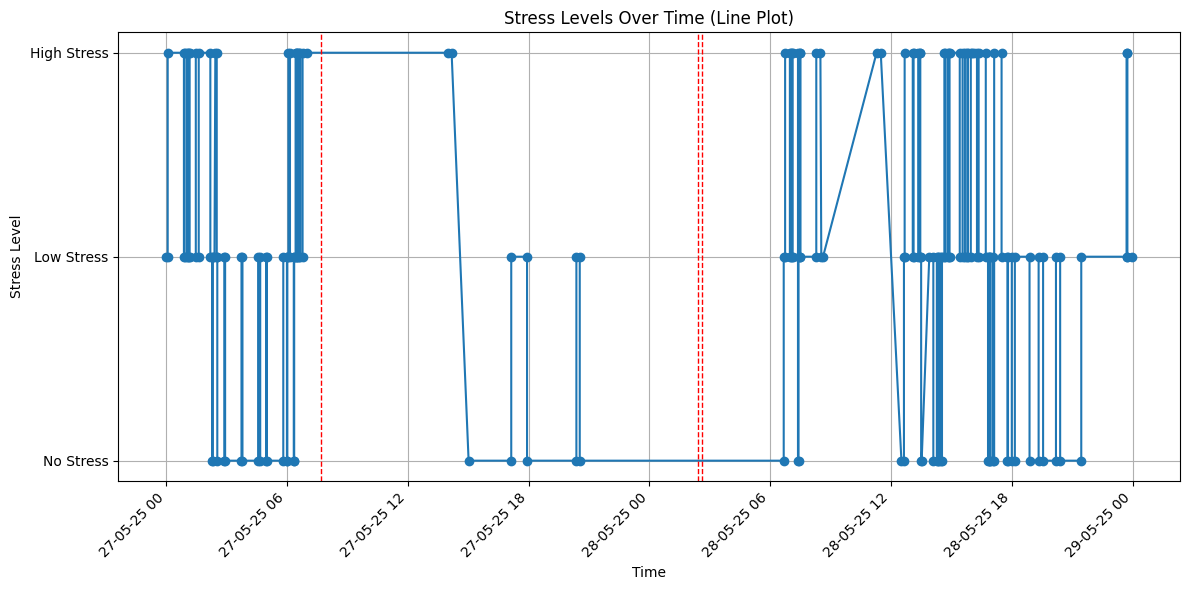

In [16]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates  # Import for date formatting

def change_event_time_to_datetime(df_temp, reference_time):
    if df_temp is None:
        print("df_temp empty")
        return None
    display(reference_time)
    # display(df_temp)
    stress_start = 0
    stress_end = 0
    tse = 0
    previous_stress = -1
    event_data = []
    time_points = []
    stress_levels = []
    if len(df_temp) < 1:
        return None
        display(df_temp)
        print("*** empty ***")
    for index, row in df_temp.iterrows():
        if row['stress'] == previous_stress:
            stress_end = row['end']
        else:
            if (previous_stress != -1):
                print(stress_start)
                start_dt_aware = reference_time + timedelta(seconds=stress_start * 5)
                end_dt_aware = reference_time + timedelta(seconds=stress_end * 5)
                timediff = end_dt_aware - start_dt_aware
                print('Prev:', index, timediff, start_dt_aware, end_dt_aware, previous_stress)
                event_data.append(
                    {'start_time': start_dt_aware, 'end_time': end_dt_aware, 'stress_level': previous_stress,
                     'duration': timediff})
                time_points.extend([start_dt_aware, end_dt_aware])
                stress_levels.extend([previous_stress, previous_stress])
    
            stress_start = row['start']
            stress_end = row['end']
            previous_stress = row['stress']
    
    if previous_stress != -1:
        print("**", stress_start)
        start_seconds = reference_time + timedelta(seconds=int(stress_start) * 5)
        end_seconds = reference_time + timedelta(seconds=int(stress_end) * 5)
        start_dt_aware =start_seconds
        end_dt_aware = end_seconds
        timediff = end_dt_aware - start_dt_aware
        print('Final:', timediff, start_dt_aware, end_dt_aware, previous_stress)
        event_data.append(
            {'start_time': start_dt_aware, 'end_time': end_dt_aware, 'stress_level': previous_stress,
             'duration': timediff})
        time_points.extend([start_dt_aware, end_dt_aware])
        stress_levels.extend([previous_stress, previous_stress])

    df_stress_events = pd.DataFrame(event_data)
    return time_points, stress_levels, df_stress_events

time_points = []
stress_levels = []
df_stress_events_list = []
all_stress_events =  None
for i, df_temp in enumerate(df_temps): 
    if df_temp is not None:
        temp_time_points, temp_stress_levels, temp_df_stress_events = change_event_time_to_datetime(df_temp, reference_times[i])
        time_points.extend(temp_time_points)
        stress_levels.extend(temp_stress_levels)
        print(i, type(temp_df_stress_events))
      
        if all_stress_events is None:
            all_stress_events = temp_df_stress_events
        else:
            try:
                all_stress_events = pd.concat([all_stress_events, temp_df_stress_events])
            except Exception as e:
                print(e)
                print(f"temp_df_stress_events {temp_df_stress_events}")

valid_tags_df = pd.read_csv(
    "../../data/embrace_plus/participants_extra_data/valid_tags/" + user + "_valid_tags.csv", sep=',')
if not valid_tags_df.empty:
    # Notice: manually replace in valid tags csv the " IDT" with "+03:00"
    valid_tags_df["datetime"] = pd.to_datetime(valid_tags_df['timestamp']).dt.tz_convert(jerusalem_tz) # Convert to Jerusalem time
    # display(valid_tags_df)

# Ensure start_dt is timezone-aware for comparison
if 'start_time' in all_stress_events.columns and not all_stress_events.empty and not valid_tags_df.empty:
    start_dt_plot = all_stress_events['start_time'].iloc[0].date()
    # data_valid_tags_df = valid_tags_df[(valid_tags_df["datetime"].dt.date == start_dt_plot)]
    data_valid_tags_df = valid_tags_df[(valid_tags_df["datetime"].dt.date == start_time.date()) | (valid_tags_df["datetime"].dt.date == end_time.date())]
else:
    data_valid_tags_df = pd.DataFrame() # Create an empty DataFrame if all_stress_events is empty

display(valid_tags_df)
plt.figure(figsize=(12, 6))
if not all_stress_events.empty:
    # Sort time points to create a continuous line
    sorted_indices = sorted(range(len(time_points)), key=lambda k: time_points[k])
    sorted_time_points = [time_points[i] for i in sorted_indices]
    sorted_stress_levels = [stress_levels[i] for i in sorted_indices]

    plt.plot(sorted_time_points, sorted_stress_levels, marker='o', linestyle='-')

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y %H', tz=jerusalem_tz))
    
    plt.yticks([0, 1, 2], ['No Stress', 'Low Stress', 'High Stress'])
    plt.xlabel('Time')
    plt.ylabel('Stress Level')
    plt.title('Stress Levels Over Time (Line Plot)')
    plt.grid(True)
    plt.xticks(rotation=45, ha='right')  # Rotate by 45 degrees and right-align
    plt.tight_layout()  # Adjust layout to prevent labels from being cut off
    # Add vertical lines for valid tags
    for _, row in data_valid_tags_df.iterrows():
        if row['severity'] > 2:
            plt.axvline(x=row['datetime'], color='red', linestyle='--', linewidth=1)
        elif row['severity'] > 0:
            plt.axvline(x=row['datetime'], color='orange', linestyle='--', linewidth=1)
        else:
            plt.axvline(x=row['datetime'], color='green', linestyle='--', linewidth=1)

    plt.show()
else:
    print("\nNo stress events to visualize.")